<a href="https://colab.research.google.com/github/Mou9tafa/Mou9tafa-Skin-disease-project/blob/main/code/GRAD_CAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Model loaded successfully ✔️


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_1']
Received: inputs=Tensor(shape=(1, 380, 380, 3))
  warnings.warn(msg)


Predicted Disease : Psoriasis
Confidence        : 95.36%


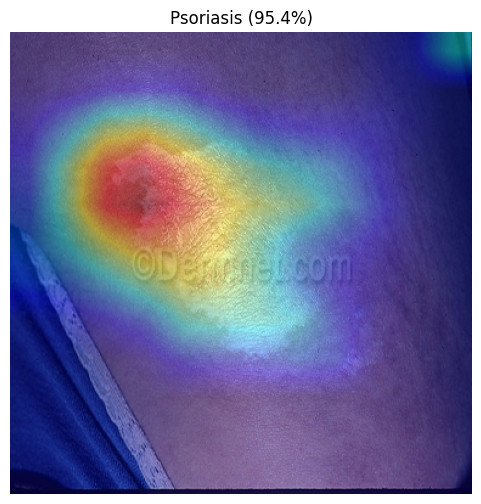

Grad-CAM saved ✔️


In [ ]:
# ===============================
# 1) Imports
# ===============================
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input


# ===============================
# 2) Focal Loss (للود الموديل)
# ===============================
def focal_loss(gamma=1.5, alpha=0.45):
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        loss = weight * ce
        return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))
    return focal_loss_fixed


# ===============================
# 3) Load Model
# ===============================
model = load_model(
    "/content/drive/MyDrive/skin_models/EfficientNetB3_NEW.keras",
    custom_objects={
        "focal_loss": focal_loss,
        "focal_loss_fixed": focal_loss(gamma=1.5, alpha=0.45),
        "loss": focal_loss(gamma=1.5, alpha=0.45) # Added to map the 'loss' string
    }
)

print("Model loaded successfully ✔️")


# ===============================
# 4) Class Names (عدّل حسب الداتا)
# ===============================
class_names =["Acne", "Eczema", "Psoriasis", "Warts", "Vitiligo"]




# ===============================
# 5) Load & Preprocess Image
# ===============================
img_path = "/content/drive/MyDrive/splitted_data/test/Psoriasis/t-Lichen-Sclerosus-Skin-128.jpg"

img_pil = image.load_img(img_path, target_size=(380, 380))
img_array = image.img_to_array(img_pil)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)


# ===============================
# 6) Prediction + Grad-CAM
# ===============================
def predict_and_gradcam(img_array, model, class_names):
    # Ensure the model is built by calling it once
    _ = model(img_array)

    efficientnet_layer = model.layers[0] # The EfficientNetB3 part
    last_conv_layer_output = efficientnet_layer.get_layer("top_conv").output

    # Manually trace the final output from the efficientnet_layer's output
    x = efficientnet_layer.output
    for layer in model.layers[1:]:
        x = layer(x)
    final_prediction_output = x

    grad_model = tf.keras.models.Model(
        inputs=efficientnet_layer.input, # Use the input of the EfficientNetB3 part
        outputs=[
            last_conv_layer_output,
            final_prediction_output # Use the manually traced final output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_index = tf.argmax(predictions[0])
        loss = predictions[:, class_index]

    # Prediction
    predicted_class = class_names[int(class_index)]
    confidence = float(predictions[0][class_index])

    # Gradients
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8

    return heatmap.numpy(), predicted_class, confidence


# ===============================
# 7) Run Everything
# ===============================
heatmap, disease, prob = predict_and_gradcam(
    img_array,
    model,
    class_names
)

print(f"Predicted Disease : {disease}")
print(f"Confidence        : {prob*100:.2f}%")


# ===============================
# 😎 Overlay Grad-CAM
# ===============================
img = cv2.imread(img_path)
img = cv2.resize(img, (380, 380))

heatmap = cv2.resize(heatmap, (380, 380))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

overlay = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)


# ===============================
# 9) Display Result
# ===============================
plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title(f"{disease} ({prob*100:.1f}%)")
plt.axis("off")
plt.show()


# ===============================
# 10) Save Result (اختياري)
# ===============================
cv2.imwrite("gradcam_result.jpg", overlay)
print("Grad-CAM saved ✔️")